In [1]:
# import libraries
import pandas as pd
import numpy as np

In [3]:
# Load the Dataset
df = pd.read_csv('weight-height.csv')
# Top-5 rows
df.head(5)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [6]:
# shape of the 'Heigth' column
df['Height'].shape

(10000,)

In [7]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

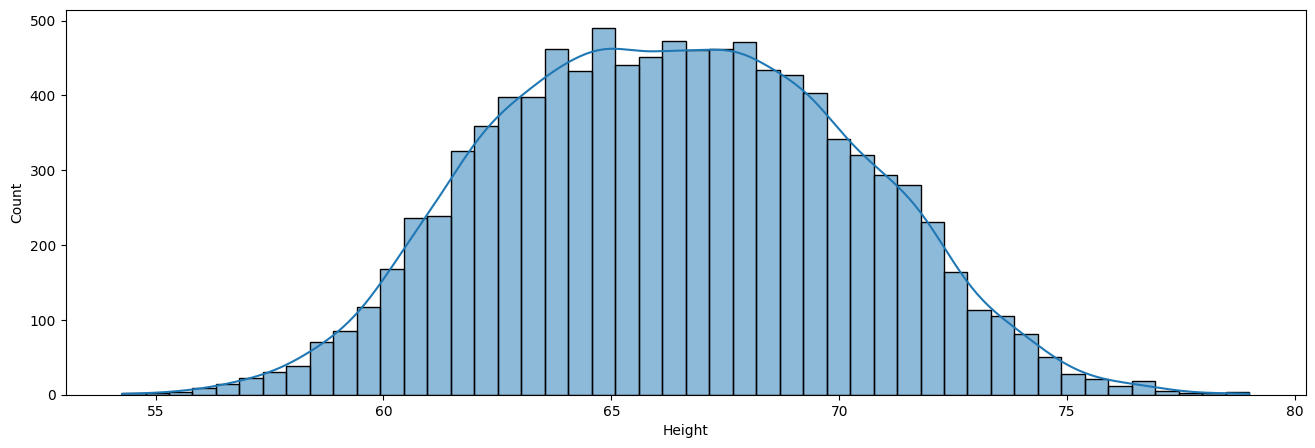

In [11]:
# import matplolib
import matplotlib.pyplot as plt
# import seaborn
import seaborn as sns

# Figure Size of the chart
plt.figure(figsize=(16,5))
sns.histplot(data=df['Height'], kde=True)
# show plot
plt.show()

<Axes: xlabel='Height'>

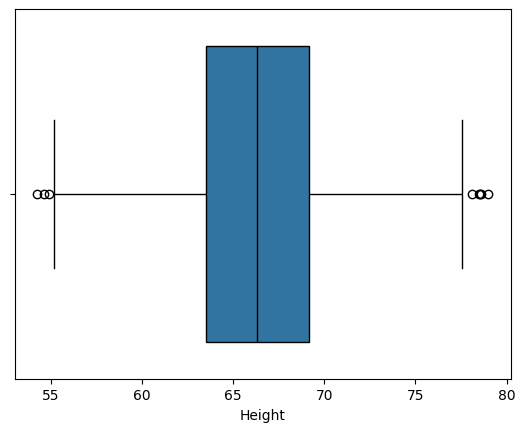

In [17]:
# Make a boxplot()
sns.boxplot(df['Height'], orient='h', linecolor='black')

In [19]:
# Let calculate teh upper_limit
upper_lmt = df['Height'].quantile(0.99)
lower_lmt = df['Height'].quantile(0.01)

# print lower_lmt and upper_lmt
print('upper limit:',upper_lmt)
print('lower_limit:',lower_lmt)

upper limit: 74.7857900583366
lower_limit: 58.13441158671655


In [21]:
# Get the DataFrame that should not be.
# Change the inequality, to get the DataFrame after removing outlier.
df[(df['Height'] >= 74.78 ) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [23]:
# Get the DataFrame that should be, No outlier.
new_df = df[(df['Height'] <= 74.78 ) & (df['Height'] >= 58.13)]

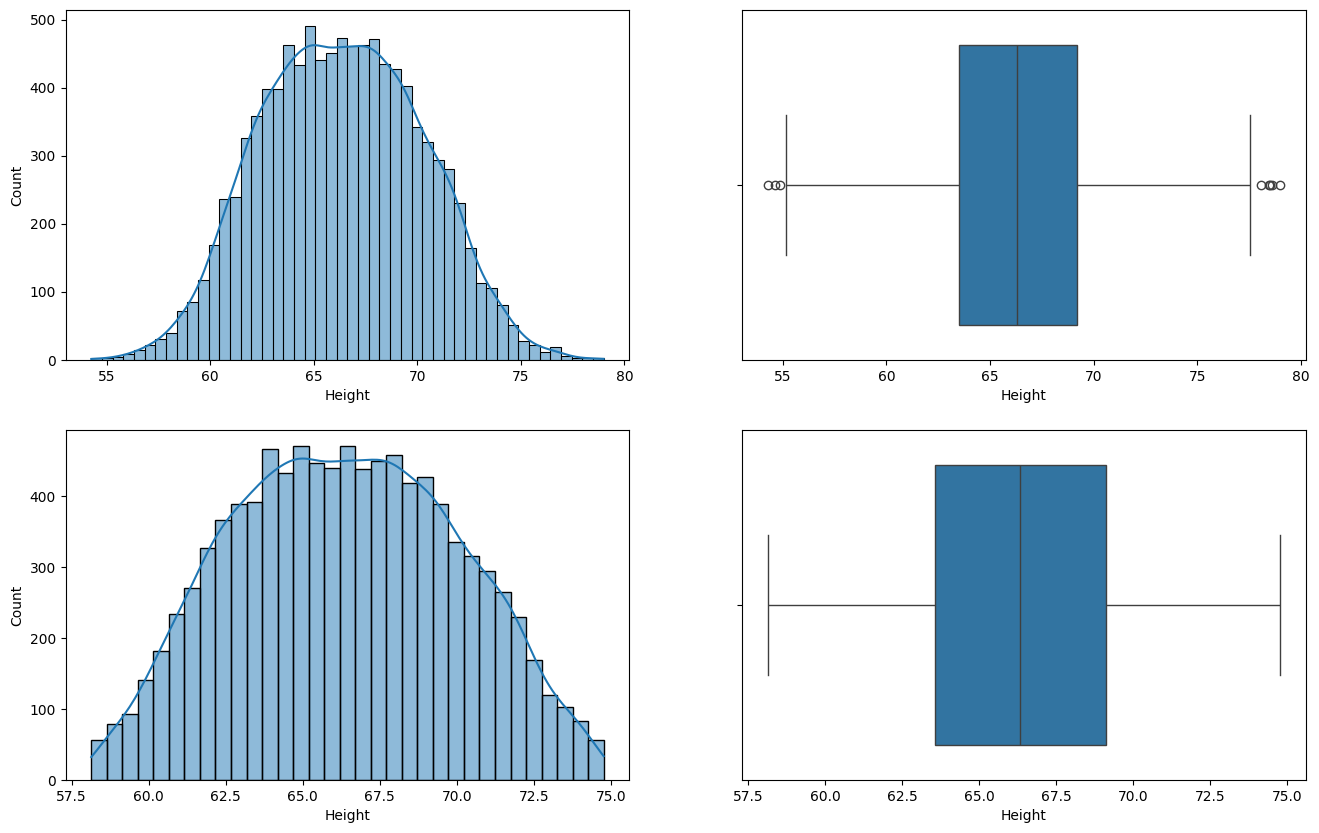

In [30]:
# Plot the Before and After the graph.
plt.figure(figsize=(16,10))

# plot-1
plt.subplot(2,2,1)
sns.histplot(data=df['Height'], kde=True)

# plot-2
plt.subplot(2,2,2)
sns.boxplot(data=df['Height'], orient='h')

# plot-3
plt.subplot(2,2,3)
sns.histplot(data=new_df['Height'], kde=True)

# plot-4
plt.subplot(2,2,4)
sns.boxplot(data=new_df['Height'], orient='h')

# show the plot()
plt.show()

## *Capping--> windorization*

In [33]:
# np.where([condition], [True], [False])
df['Height'] = np.where(
    df['Height'] >= upper_lmt,
    upper_lmt,
    np.where(
        df['Height'] <= lower_lmt,
        lower_lmt,
        df['Height']
    ) 
)

<Axes: ylabel='Density'>

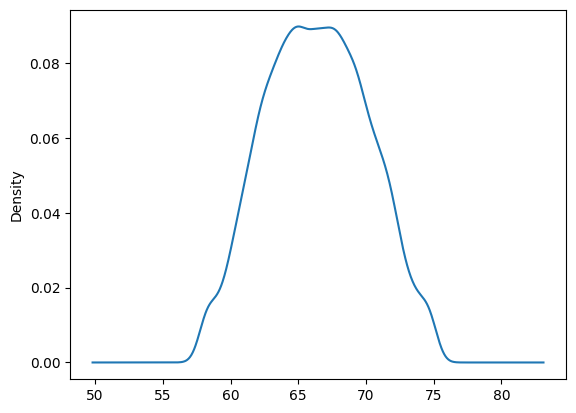

In [38]:
df['Height'].plot(kind='kde')